# 23CSE301 Machine Learning - Capstone Project
## Regression Track

**Dataset:** Diabetes Prediction Dataset - 100,000 records, 9 columns
**Target:** `blood_glucose_level` - continuous, measured in mg/dL
**Task:** supervised regression

### Problem statement

Predict a patient's blood glucose level from routinely collected demographic and
clinical measurements: age, sex, BMI, HbA1c, smoking history, hypertension and
heart disease.

### Reproducibility

`random_state = 42` is applied to the train/test split, to every estimator that
accepts a seed, to every cross-validation fold and to the row samples used for
plotting. The encoder and the scaler are fitted on the training split only.

### Scope

Ten regression algorithms, all trained on the same preprocessed training split and
scored on the same held-out test set, reported as one ranked table on R squared,
RMSE and MAE, with 5-fold cross-validated R squared for the two best models.

---
# 1. Data Loading and Audit

## 1.1 Imports and configuration

One cell fixes the seed and imports everything the notebook uses, so that no later
cell depends on an import buried further down.


In [1]:
# CELL 1: Setup & Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("REGRESSION MODEL — SETUP")
print("=" * 60)
print("All required libraries imported successfully.")
print(f"Random state: {RANDOM_STATE}")
print("=" * 60)

REGRESSION MODEL — SETUP
All required libraries imported successfully.
Random state: 42


## 1.2 Load the dataset

The CSV is read from `../data/`, so the notebook runs on a fresh clone with no
download step.


In [2]:
# CELL 2: Load Dataset

DATA_PATH = "../data/diabetes_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET LOADING")
print("=" * 60)
print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("=" * 60)

DATASET LOADING
Dataset loaded successfully.
Rows    : 100,000
Columns : 9


## 1.3 Preview and structure

The first five records and the column list, to confirm the file parsed into the
columns expected rather than a single malformed column.


In [3]:
# CELL 3: Initial Data Preview

print("=" * 60)
print("INITIAL DATA PREVIEW")
print("=" * 60)

display(df.head())

print("\nFirst 5 records displayed successfully.")

INITIAL DATA PREVIEW


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



First 5 records displayed successfully.


In [4]:
# CELL 4: Dataset Structure

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print(f"\nDataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

print("\nData types:")
display(df.dtypes.rename("Data Type").to_frame())

print("=" * 60)

DATASET STRUCTURE

Dataset shape : 100,000 rows × 9 columns

Column names:
 1. gender
 2. age
 3. hypertension
 4. heart_disease
 5. smoking_history
 6. bmi
 7. HbA1c_level
 8. blood_glucose_level
 9. diabetes

Data types:


,Data Type
gender,str
age,float64
hypertension,int64
heart_disease,int64
smoking_history,str
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


## 1.4 Missing values and duplicates

Both are measured before anything is changed, so the cleaning step in section 3 can
be justified by a number rather than by habit.


In [5]:
# CELL 5: Missing Value Analysis

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

display(missing)

total_missing = df.isnull().sum().sum()

print(f"\nTotal missing values: {total_missing:,}")

if total_missing == 0:
    print("No missing values detected.")
else:
    print("Missing values detected. Further treatment is required.")

print("=" * 60)

MISSING VALUE ANALYSIS


,Missing Values,Missing (%)
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0



Total missing values: 0
No missing values detected.


In [6]:
# CELL 6: Duplicate Record Analysis

duplicate_count = df.duplicated().sum()

print("=" * 60)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 60)

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count == 0:
    print("No duplicate records detected.")
else:
    print("Duplicate records detected.")

print("=" * 60)

DUPLICATE RECORD ANALYSIS
Duplicate rows: 3,854
Duplicate records detected.


## 1.5 Descriptive statistics

Count, mean, standard deviation and the five-number summary for every numeric
column. This is where the shape of the target first becomes visible.


In [7]:
# CELL 7: Descriptive Statistics

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe().T.round(2))

print("=" * 60)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.89,22.52,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.07,0.26,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.32,6.64,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.53,1.07,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.06,40.71,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.08,0.28,0.00,0.00,0.00,0.00,1.00


### Observation - 1

- 100,000 rows and 9 columns, with **no missing values** anywhere in the frame.
- **3,854 exact duplicate rows**, 3.85% of the dataset.
- `bmi` has a mean of 27.32 and a median of also exactly 27.32, with a maximum of 95.69.
- `blood_glucose_level` runs from 80 to 300 with a mean of 138.06 and a standard deviation of 40.71.
- `HbA1c_level` runs from 3.50 to 9.00 with a mean of 5.53.
- `hypertension`, `heart_disease` and `diabetes` are 0/1 flags stored as `int64`, so `describe()` reports them as if they were continuous.
- `age` is stored as a float and ranges from 0.08 to 80.


---
# 2. Exploratory Data Analysis

All EDA runs on the raw, unsplit frame. That is legitimate because it is purely
descriptive: nothing measured here is fed into a fitted transformer. Every
transformer that learns a parameter is fitted on the training split alone in
section 3.

## 2.1 Categorical feature levels

Value counts per categorical column, to see the cardinality and to check for levels
that record missingness rather than a real category.


In [8]:
# CELL 8: Categorical Feature Analysis

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

print(f"Categorical features: {len(categorical_columns)}")

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 40)
    display(df[column].value_counts(dropna=False).to_frame("Count"))

print("=" * 60)

CATEGORICAL FEATURE ANALYSIS
Categorical features: 2

gender
----------------------------------------


,Count
gender,
Female,58552
Male,41430
Other,18



smoking_history
----------------------------------------


,Count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


### Observation - 2.1

- `gender` has three levels: Female 58,552, Male 41,430, and **Other with only 18 records**.
- `smoking_history` has six levels, the largest being **"No Info" with 35,816 records, 35.8% of the dataset**.
- "No Info" is not a smoking behaviour, it is missingness recorded as a category. It is left as its own level rather than imputed, because guessing a smoking history for a third of the dataset would invent data.
- Both columns are low-cardinality and nominal, which is what makes one-hot encoding appropriate in 3.5.


## 2.2 Distribution of each numeric feature

The chart type is chosen by how many distinct values a column actually takes, not
by its dtype. A kernel density estimate assumes a continuous variable; drawing one
over a 0/1 flag would put density at values such as 0.3, which no patient can have.
Flags therefore get a count plot, heavily discretised columns get one bar per value,
and only genuinely continuous columns get a histogram with a KDE.


In [ ]:
# CELL 9: Numerical Feature Distributions

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


def plot_numeric_distribution(series, figsize=(8, 5)):
    """Pick the chart that matches what the column actually contains.

    A KDE assumes a continuous variable. hypertension, heart_disease and
    diabetes are 0/1 flags, and the two glycaemic markers take only 18
    distinct values each, so smoothing either kind would draw density at
    values the column can never take - a patient who is 0.3 hypertensive.
    """
    n_unique = series.nunique()
    plt.figure(figsize=figsize)

    if n_unique == 2:
        # yes/no flag: two labelled bars and the positive rate
        counts = series.value_counts().sort_index()
        bars = plt.bar(counts.index.astype(str), counts.values)
        plt.bar_label(bars, labels=[f"{v:,}" for v in counts.values])
        plt.xticks([0, 1], ["no (0)", "yes (1)"])
        plt.ylabel("Count")
        plt.title(f"Distribution of {series.name} - {series.mean():.2%} positive")

    elif n_unique <= 25:
        # heavily discretised: one bar per value it can actually take
        counts = series.value_counts().sort_index()
        gaps = np.diff(counts.index.values)
        width = (gaps.min() * 0.8) if len(gaps) else 0.8
        plt.bar(counts.index, counts.values, width=width)
        plt.ylabel("Count")
        plt.title(f"Distribution of {series.name} - {n_unique} distinct values")

    else:
        sns.histplot(series, kde=True)
        plt.ylabel("Frequency")
        plt.title(f"Distribution of {series.name}")

    plt.xlabel(series.name)
    plt.tight_layout()
    plt.show()


binary_columns = [c for c in numerical_columns if df[c].nunique() == 2]
discrete_columns = [c for c in numerical_columns
                    if c not in binary_columns and df[c].nunique() <= 25]
continuous_columns = [c for c in numerical_columns
                      if c not in binary_columns and c not in discrete_columns]

print("=" * 60)
print("NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 60)
print(f"Continuous (histogram + KDE): {continuous_columns}")
print(f"Discrete (one bar per value): {discrete_columns}")
print(f"Binary flags (count plot):    {binary_columns}")
print("=" * 60)

for column in numerical_columns:
    plot_numeric_distribution(df[column])

print("=" * 60)


### Observation - 2.2

- Only `age` and `bmi` are continuous enough to justify a KDE.
- `HbA1c_level` and `blood_glucose_level` each take **only 18 distinct values** across 100,000 records.
- `bmi` is right-skewed, and the single value 27.32 is repeated far more often than any other.
- Positive rates on the three flags: `hypertension` 7.49%, `heart_disease` 3.94%, `diabetes` 8.50%.
- `age` is broadly flat across the adult range rather than bell-shaped.
- The 18-value structure of the target is the single most important fact in this notebook, and section 6 returns to it.


## 2.3 Distribution of the categorical features

Counts per level for `gender` and `smoking_history`.


CATEGORICAL FEATURE DISTRIBUTIONS


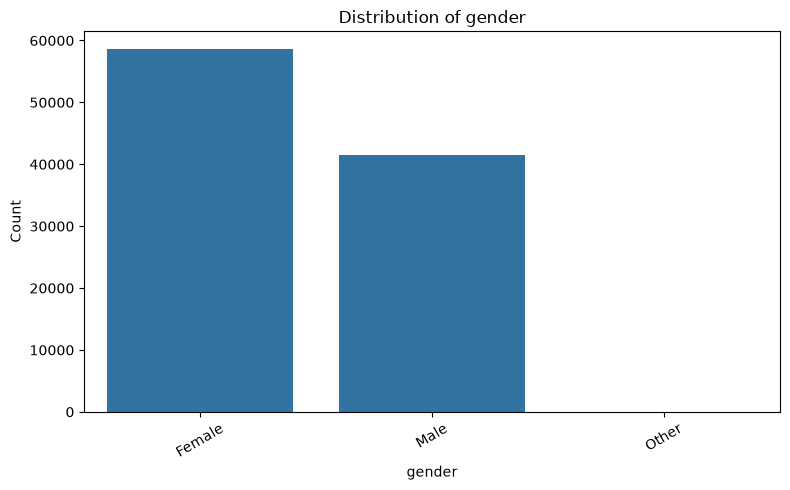

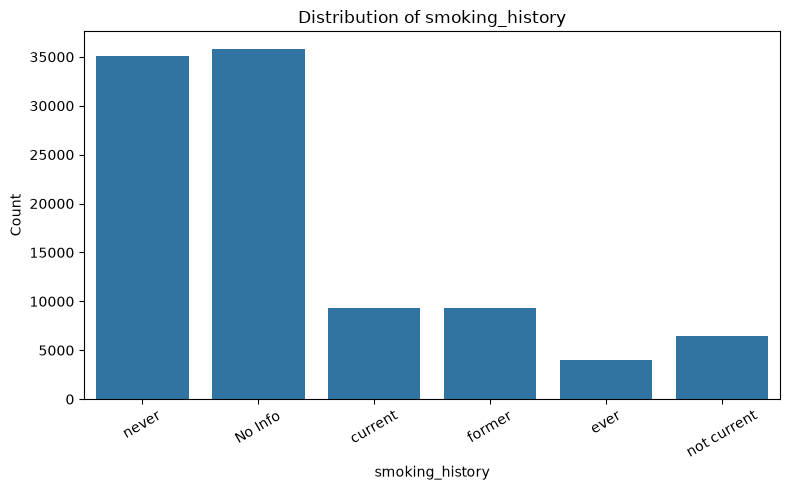

In [10]:
# CELL 10: Categorical Feature Distributions

print("=" * 60)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

for column in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

print("=" * 60)

## 2.4 Correlation heatmap

Pearson correlation across the numeric columns, to see which features move with the
target and whether any predictors duplicate one another.

The colour scale is anchored to the interval [-1, +1] with white at 0. Without that
anchoring the scale stretches to fit whatever happens to be in the matrix, and a
correlation of 0.05 can render in the same strong colour as one of 0.9.


In [ ]:
# CELL 11: Correlation Heatmap

print("=" * 60)
print("CORRELATION HEATMAP")
print("=" * 60)

correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

# hide the top half: A-vs-B is the same number as B-vs-A
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    # without these three the colour scale stretches to fit whatever is in the
    # matrix, so r = 0.05 can render as strongly red and 0 is not white.
    # anchoring to [-1, +1] with white at 0 keeps the colours readable as
    # correlations rather than as ranks within this particular matrix.
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson r"}
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

print("=" * 60)


### Observation - 2.4

- Correlation with the target `blood_glucose_level`: `diabetes` **+0.4196**, `HbA1c_level` +0.1667, `age` +0.1107, `bmi` +0.0913, `hypertension` +0.0844, `heart_disease` +0.0701.
- **Only one feature correlates with the target above 0.17, and that feature is `diabetes`** - which is itself derived from blood glucose, since a diabetes diagnosis is made partly on this measurement.
- Setting `diabetes` aside, the strongest remaining predictor is `HbA1c_level` at 0.1667, and squaring that gives about 0.028 of shared variance.
- No pair of predictors is strongly correlated with any other predictor.
- This heatmap already predicts the result in section 5: with no strong linear predictor available, no linear model can achieve a high R squared here.


## 2.5 Choosing the regression target

Two continuous-looking candidates exist in this dataset, `HbA1c_level` and
`blood_glucose_level`. Both are inspected before one is chosen, since the choice
determines everything downstream.


In [ ]:
# CELL 12: Candidate Target Distributions

target_candidates = ["HbA1c_level", "blood_glucose_level"]

print("=" * 60)
print("CANDIDATE TARGET DISTRIBUTIONS")
print("=" * 60)

for column in target_candidates:
    # plot_numeric_distribution is defined in CELL 9. both markers take only
    # 18 distinct values, so they are drawn as one bar per value rather than
    # smoothed with a KDE across the gaps between them.
    plot_numeric_distribution(df[column])

    print(f"{column} statistics:")
    print(df[column].describe().round(2))
    print(f"distinct values: {df[column].nunique()}")
    print("-" * 60)

print("=" * 60)


### Observation - 2.5

- `HbA1c_level`: 18 distinct values, range 3.50 to 9.00, mean 5.53, standard deviation 1.07.
- `blood_glucose_level`: 18 distinct values, range 80 to 300, mean 138.06, standard deviation 40.71.
- **Both candidates are discretised to 18 levels.** Neither is a continuous measurement in the sense that regression assumes.
- `blood_glucose_level` is chosen because its wider range and larger variance leave more variation for a model to explain, and because it is the more clinically direct quantity.
- The bars are visibly clustered rather than smooth: the values below 6.6 on HbA1c and below 200 on glucose hold the overwhelming majority of records, and the upper values are sparse.


## 2.6 Feature-target relationships

Two scatter plots of a feature against the target, as the rubric requires.

With 100,000 records a raw scatter is a solid block of ink, and because the target
takes only 18 values the points collapse onto 18 horizontal stripes. Each panel is
therefore drawn from a reproducible 6,000-row sample, with the mean target per
decile of the feature overlaid. The sampling changes the picture only, never the
modelling.


In [ ]:
# CELL 13: Regression Target and Feature-Target Relationships

# Set the regression target chosen by the team
target_column = "blood_glucose_level"

print("=" * 60)
print("REGRESSION TARGET")
print("=" * 60)
print(f"Selected target: {target_column}")

# Select two numerical features for visualization
feature_1 = "age"
feature_2 = "bmi"

print(f"\nFeature 1: {feature_1}")
print(f"Feature 2: {feature_2}")

print("=" * 60)

# 100,000 dots on one axis is a solid block, and the target only takes 18
# distinct values, so a raw scatter collapses into 18 flat stripes and shows
# nothing. Plot a 6,000-row sample for the cloud and overlay the mean target
# per decile of the feature - that red line is the trend the regression models
# are actually trying to fit, and how flat it is, is the result.
SCATTER_N = 6_000
df_sample = df.sample(n=min(SCATTER_N, len(df)), random_state=RANDOM_STATE)

for feature in (feature_1, feature_2):
    plt.figure(figsize=(8, 5))

    plt.scatter(
        df_sample[feature],
        df_sample[target_column],
        s=10,
        alpha=0.20,
        edgecolors="none",
        label=f"{SCATTER_N:,}-row sample"
    )

    feature_bins = pd.qcut(df[feature], q=10, duplicates="drop")
    binned_mean = df.groupby(feature_bins, observed=True)[target_column].mean()

    plt.plot(
        [interval.mid for interval in binned_mean.index],
        binned_mean.values,
        color="crimson",
        marker="o",
        linewidth=2,
        label=f"mean {target_column} per decile"
    )

    plt.title(f"{feature} vs {target_column}")
    plt.xlabel(feature)
    plt.ylabel(target_column)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("=" * 60)


### Observation - 2.6

- The 18 horizontal stripes are the target's own discreteness, not a plotting artefact.
- Across the deciles of `age`, mean blood glucose moves from roughly 132 to 147 mg/dL - a spread of about 15 mg/dL against a target standard deviation of 40.71.
- Across the deciles of `bmi` the decile-mean line is similarly shallow.
- Neither panel shows a usable linear relationship. **The overlaid mean line is close to flat in both, which is what an R squared near 0.18 looks like before any model is fitted.**
- There is no visible interaction or curvature that a polynomial term would obviously capture.


---
# 3. Preprocessing and Feature Engineering

### Order of operations

The sequence is deliberate, and it is what keeps test data out of the training
pipeline.

| Step | Operation | Applied to | Safe because |
|------|-----------|------------|--------------|
| 3.1 | Measure duplicates and IQR outliers | full frame | reporting only, nothing is fitted |
| 3.2 | Drop exact duplicates | full frame | row identity only, no statistics |
| 3.3 | Engineer `age_bmi_interaction` | full frame | strictly row-wise, uses no other row |
| 3.4 | `train_test_split` | - | the split itself |
| 3.5 | One-hot encode and scale | **after the split** | `.fit()` sees `X_train` only |

## 3.1 Cleaning audit

Duplicates and Tukey IQR fences are measured here and acted on in 3.2. For each
numeric column, values outside

$$[\,Q_1 - 1.5 \times IQR,\;\; Q_3 + 1.5 \times IQR\,] \qquad IQR = Q_3 - Q_1$$

are flagged.


In [14]:
# CELL 14: Data Cleaning Check

print("=" * 60)
print("DATA CLEANING CHECK")
print("=" * 60)

# Missing values
missing_values = df.isnull().sum().sum()

# Duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Total missing values : {missing_values:,}")
print(f"Duplicate rows       : {duplicate_rows:,}")

# Numerical columns for outlier inspection
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nPotential outliers using IQR method:")
print("-" * 60)

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

print("=" * 60)

DATA CLEANING CHECK


Total missing values : 0
Duplicate rows       : 3,854

Potential outliers using IQR method:
------------------------------------------------------------


,Feature,Lower Bound,Upper Bound,Outlier Count
0,age,-30.0,114.0,0
1,hypertension,0.0,0.0,7485
2,heart_disease,0.0,0.0,3942
3,bmi,14.7,38.5,7086
4,HbA1c_level,2.7,8.3,1315
5,blood_glucose_level,11.5,247.5,2038
6,diabetes,0.0,0.0,8500


### Observation - 3.1

- 3,854 exact duplicate rows and no missing values.
- IQR flags: `bmi` 7,086 rows, `blood_glucose_level` 2,038, `HbA1c_level` 1,315, and `age` none at all - its fences, -30 to 114, fall outside the range the column can take.
- **The IQR rule is meaningless for the three binary flags.** For a 0/1 column $Q_1 = Q_3 = 0$, so the fences collapse to [0, 0] and every positive case is flagged. The 7,485, 3,942 and 8,500 counts reported for `hypertension`, `heart_disease` and `diabetes` are simply the number of 1s in each column, not outliers.
- The flagged `bmi` rows are clinically plausible values, not data errors: a BMI of 40 is a real measurement.
- Treatment is therefore **no outlier removal and no clipping**, which 3.2 states explicitly. Deleting them would discard valid extreme patients, and this dataset gives no evidence that they are recording errors.


## 3.2 Cleaning

Exact duplicates are removed. A record identical across all nine fields is far more
likely to be an export artefact than two genuinely distinct patients, and leaving
them in lets the same row land in both the training and the test split, which
inflates the test score.


In [15]:
# CELL 15: Data Cleaning

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Remove duplicate rows
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
duplicates_removed = rows_before - rows_after

print(f"Rows before removing duplicates : {rows_before:,}")
print(f"Duplicate rows removed          : {duplicates_removed:,}")
print(f"Rows after removing duplicates  : {rows_after:,}")

# Check missing values again
remaining_missing = df.isnull().sum().sum()

print(f"\nRemaining missing values        : {remaining_missing:,}")

if remaining_missing == 0:
    print("No missing values remain.")

# Outlier decision
print("\nOutlier treatment:")
print("- Binary variables are not treated as outliers.")
print("- Valid extreme numerical observations are retained.")
print("- No arbitrary outlier deletion or clipping is applied.")

print("=" * 60)

DATA CLEANING
Rows before removing duplicates : 100,000
Duplicate rows removed          : 3,854
Rows after removing duplicates  : 96,146

Remaining missing values        : 0
No missing values remain.

Outlier treatment:
- Binary variables are not treated as outliers.
- Valid extreme numerical observations are retained.
- No arbitrary outlier deletion or clipping is applied.


## 3.3 Feature engineering

**Feature: `age_bmi_interaction` = `age` x `bmi`.**

**Why it might help.** A linear model computes a weighted sum of its inputs, so it
can represent "risk rises with age" and "risk rises with BMI" separately, but it
**cannot represent "the effect of BMI is larger in older patients"** unless the
product of the two is supplied as its own column. Metabolic risk is generally
understood to compound in exactly that way rather than to add.

The feature is **strictly row-wise**: it is computed from that record's own two
values and nothing else. No statistic is calculated across rows, so creating it
before the train/test split leaks nothing.


In [16]:
# CELL 16: Feature Engineering

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create an interaction feature between age and BMI
df["age_bmi_interaction"] = df["age"] * df["bmi"]

print("New feature created:")
print("age_bmi_interaction = age × bmi")

print("\nUpdated dataset shape:")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nPreview of the engineered feature:")
display(
    df[["age", "bmi", "age_bmi_interaction"]].head()
)

print("=" * 60)

FEATURE ENGINEERING
New feature created:
age_bmi_interaction = age × bmi

Updated dataset shape:
Rows    : 96,146
Columns : 10

Preview of the engineered feature:


,age,bmi,age_bmi_interaction
0,80.0,25.19,2015.20
1,54.0,27.32,1475.28
2,28.0,27.32,764.96
3,36.0,23.45,844.20
4,76.0,20.14,1530.64


## 3.4 Train/test split

The split happens now, before any transformer is fitted. Everything after this point
that estimates a parameter sees `X_train` only.

An 80/20 split is used, consistent across all ten algorithms so the comparison in
section 5 is fair.


In [17]:
# CELL 17: Target Selection and Train-Test Split

print("=" * 60)
print("TARGET SELECTION AND TRAIN-TEST SPLIT")
print("=" * 60)

# Regression target
target_column = "blood_glucose_level"

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Target variable: {target_column}")
print(f"Number of features: {X.shape[1]}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("\nTrain-test split:")
print(f"Training samples   : {X_train.shape[0]:,}")
print(f"Testing samples    : {X_test.shape[0]:,}")
print(f"Training features  : {X_train.shape[1]}")
print(f"Testing features   : {X_test.shape[1]}")

print("\nSplit ratio:")
print(f"Training: {len(X_train) / len(X) * 100:.0f}%")
print(f"Testing : {len(X_test) / len(X) * 100:.0f}%")

print("=" * 60)

TARGET SELECTION AND TRAIN-TEST SPLIT
Target variable: blood_glucose_level
Number of features: 9

Train-test split:
Training samples   : 76,916
Testing samples    : 19,230
Training features  : 9
Testing features   : 9

Split ratio:
Training: 80%
Testing : 20%


## 3.5 Encoding and scaling, fitted on the training split only

This is the cell where leakage would happen if the discipline slipped, so the
`ColumnTransformer` is fitted once on `X_train` and then merely applied to both
splits.

| Column | Treatment | Reason |
|--------|-----------|--------|
| `gender`, `smoking_history` | One-hot | Low cardinality, nominal, no natural ordering |
| all numeric columns | `StandardScaler` | SVR and KNN are distance-based and would otherwise be dominated by `bmi` and `age_bmi_interaction`, whose raw scales are far larger than a 0/1 flag |

Scaling is not merely cosmetic here. The RBF kernel in SVR computes
$\exp(-\gamma \|x - x'\|^2)$ and KNN ranks neighbours by Euclidean distance; on raw
scales `age_bmi_interaction`, which reaches into the thousands, would swamp every
other feature in that distance.


In [18]:
# CELL 18: Encoding and Scaling

print("=" * 60)
print("ENCODING AND SCALING")
print("=" * 60)

# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Categorical features: {categorical_features}")
print(f"Numerical features  : {numerical_features}")

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nPreprocessing completed successfully.")

print(f"Original training shape : {X_train.shape}")
print(f"Processed training shape: {X_train_processed.shape}")

print(f"\nOriginal testing shape  : {X_test.shape}")
print(f"Processed testing shape : {X_test_processed.shape}")

print("\nEncoding and scaling were fitted only on the training data.")
print("=" * 60)

ENCODING AND SCALING
Categorical features: ['gender', 'smoking_history']
Numerical features  : ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'diabetes', 'age_bmi_interaction']

Preprocessing completed successfully.
Original training shape : (76916, 9)
Processed training shape: (76916, 16)

Original testing shape  : (19230, 9)
Processed testing shape : (19230, 16)

Encoding and scaling were fitted only on the training data.


### Observation - 3

- Removing duplicates takes the frame from 100,000 rows to **96,146**.
- Feature engineering adds one column, giving 10 before the target is separated.
- The split gives **76,916 training rows and 19,230 test rows**, an 80/20 division.
- One-hot encoding `gender` and `smoking_history` expands 9 feature columns into **16 model columns**.
- The encoder and the scaler are fitted on `X_train` alone and then applied to both splits.
- **`diabetes` is retained as a predictor.** It is the single strongest correlate of the target at +0.4196, and section 6 measures how much of the final result rests on it.


---
# 4. Model Training

Ten regression algorithms, each trained on the same `X_train_processed` and scored
on the same held-out `X_test_processed`, so that every number in section 5 is
comparable.

Metrics reported per model are **R squared, RMSE and MAE**.

- **R squared** is measured against the mean of the target. Zero means the model ties with predicting the mean for every patient; a negative value means it does worse than that.
- **RMSE** is in mg/dL and penalises large misses quadratically.
- **MAE** is in mg/dL and reports the typical miss without that penalty.


In [19]:
# REGRESSION MODEL IMPORTS

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import numpy as np
import pandas as pd

## 4.1 Linear Regression

The baseline. It models blood glucose as a weighted sum of the standardised
features, so a coefficient reads directly as the change in mg/dL per one standard
deviation increase in that feature.


In [20]:
# ALGORITHM 1: LINEAR REGRESSION

print("=" * 70)
print("ALGORITHM 1: LINEAR REGRESSION")
print("=" * 70)

linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluation
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print(f"R² Score : {linear_r2:.4f}")
print(f"RMSE     : {linear_rmse:.4f}")
print(f"MAE      : {linear_mae:.4f}")

ALGORITHM 1: LINEAR REGRESSION
R² Score : 0.1825
RMSE     : 36.9395
MAE      : 30.7322


## 4.2 Ridge Regression

Ridge adds an L2 penalty, $\alpha \sum \beta_j^2$, which shrinks coefficients toward
zero without setting any of them to exactly zero. It is the standard remedy for
correlated predictors, whose coefficients would otherwise be unstable.


In [21]:
# ALGORITHM 2: RIDGE REGRESSION

print("=" * 70)
print("ALGORITHM 2: RIDGE REGRESSION")
print("=" * 70)

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_ridge = ridge_model.predict(X_test_processed)

# Evaluation
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print(f"R² Score : {ridge_r2:.4f}")
print(f"RMSE     : {ridge_rmse:.4f}")
print(f"MAE      : {ridge_mae:.4f}")

ALGORITHM 2: RIDGE REGRESSION
R² Score : 0.1825
RMSE     : 36.9395
MAE      : 30.7322


## 4.3 Lasso Regression

Lasso uses an L1 penalty, $\alpha \sum |\beta_j|$, which can drive coefficients to
**exactly** zero and therefore performs feature selection as part of fitting.


In [22]:
# ALGORITHM 3: LASSO REGRESSION

print("=" * 70)
print("ALGORITHM 3: LASSO REGRESSION")
print("=" * 70)

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_lasso = lasso_model.predict(X_test_processed)

# Evaluation
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print(f"R² Score : {lasso_r2:.4f}")
print(f"RMSE     : {lasso_rmse:.4f}")
print(f"MAE      : {lasso_mae:.4f}")

ALGORITHM 3: LASSO REGRESSION
R² Score : 0.1825
RMSE     : 36.9386
MAE      : 30.7316


## 4.4 ElasticNet Regression

ElasticNet combines both penalties, mixing Lasso's feature selection with Ridge's
stable shrinkage, controlled by `l1_ratio`.


In [23]:
# ALGORITHM 4: ELASTICNET REGRESSION

print("=" * 70)
print("ALGORITHM 4: ELASTICNET REGRESSION")
print("=" * 70)

elasticnet_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elasticnet_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_elasticnet = elasticnet_model.predict(X_test_processed)

# Evaluation
elasticnet_r2 = r2_score(y_test, y_pred_elasticnet)
elasticnet_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_elasticnet)
)
elasticnet_mae = mean_absolute_error(
    y_test,
    y_pred_elasticnet
)

print(f"R² Score : {elasticnet_r2:.4f}")
print(f"RMSE     : {elasticnet_rmse:.4f}")
print(f"MAE      : {elasticnet_mae:.4f}")

ALGORITHM 4: ELASTICNET REGRESSION


R² Score : 0.1825
RMSE     : 36.9386
MAE      : 30.7280


## 4.5 Polynomial Regression

Polynomial regression expands the feature matrix with powers and pairwise products
of the inputs, then fits an ordinary linear model on that expansion. This lets a
linear learner represent curvature and interactions it otherwise cannot.

Degrees 2 and 3 are compared. The cost grows quickly: on 16 input columns, degree 2
produces 152 columns and degree 3 produces 968.


In [24]:
# ALGORITHM 5: POLYNOMIAL REGRESSION
# Compare Polynomial Degrees

print("=" * 70)
print("ALGORITHM 5: POLYNOMIAL REGRESSION")
print("=" * 70)

degrees = [2, 3]

polynomial_results = []

for degree in degrees:

    polynomial_model = Pipeline([
        (
            "polynomial_features",
            PolynomialFeatures(
                degree=degree,
                include_bias=False
            )
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ])

    polynomial_model.fit(
        X_train_processed,
        y_train
    )

    y_pred_poly = polynomial_model.predict(
        X_test_processed
    )

    r2 = r2_score(y_test, y_pred_poly)
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred_poly)
    )
    mae = mean_absolute_error(
        y_test,
        y_pred_poly
    )

    polynomial_results.append({
        "Degree": degree,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    print(f"\nPolynomial Degree: {degree}")
    print(f"R² Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")

polynomial_results_df = pd.DataFrame(
    polynomial_results
)

display(polynomial_results_df)

ALGORITHM 5: POLYNOMIAL REGRESSION



Polynomial Degree: 2
R² Score : 0.1811
RMSE     : 36.9701
MAE      : 30.7474



Polynomial Degree: 3
R² Score : 0.1778
RMSE     : 37.0460
MAE      : 30.7827


,Degree,R²,RMSE,MAE
0,2,0.181133,36.970144,30.747398
1,3,0.177768,37.046024,30.782737


In [25]:
# Select the polynomial degree with the highest R²

best_degree = polynomial_results_df.loc[
    polynomial_results_df["R²"].idxmax(),
    "Degree"
]

print(f"Best Polynomial Degree: {best_degree}")
# Final Polynomial Regression Model

polynomial_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=int(best_degree),
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

polynomial_model.fit(
    X_train_processed,
    y_train
)

y_pred_polynomial = polynomial_model.predict(
    X_test_processed
)

polynomial_r2 = r2_score(
    y_test,
    y_pred_polynomial
)

polynomial_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_polynomial
    )
)

polynomial_mae = mean_absolute_error(
    y_test,
    y_pred_polynomial
)

print("\nFinal Polynomial Regression Results")
print("-" * 50)
print(f"R² Score : {polynomial_r2:.4f}")
print(f"RMSE     : {polynomial_rmse:.4f}")
print(f"MAE      : {polynomial_mae:.4f}")

Best Polynomial Degree: 2



Final Polynomial Regression Results
--------------------------------------------------
R² Score : 0.1811
RMSE     : 36.9701
MAE      : 30.7474


## 4.6 Decision Tree Regressor

A decision tree partitions the feature space with axis-aligned splits and predicts
the mean of the training targets in each leaf. It is fitted here **unconstrained**,
which is deliberate: the result is the clearest demonstration of overfitting in the
notebook, and section 5.3 then tunes it.


In [26]:
# ALGORITHM 6: DECISION TREE REGRESSOR

from sklearn.tree import DecisionTreeRegressor

print("=" * 70)
print("ALGORITHM 6: DECISION TREE REGRESSOR")
print("=" * 70)

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_decision_tree = decision_tree_model.predict(
    X_test_processed
)

# Evaluation
decision_tree_r2 = r2_score(
    y_test,
    y_pred_decision_tree
)

decision_tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_decision_tree
    )
)

decision_tree_mae = mean_absolute_error(
    y_test,
    y_pred_decision_tree
)

print(f"R² Score : {decision_tree_r2:.4f}")
print(f"RMSE     : {decision_tree_rmse:.4f}")
print(f"MAE      : {decision_tree_mae:.4f}")

ALGORITHM 6: DECISION TREE REGRESSOR


R² Score : -0.6536
RMSE     : 52.5360
MAE      : 40.9233


## 4.7 Random Forest Regressor

An ensemble of decision trees, each fitted on a bootstrap sample with a random
subset of features considered at each split, averaged. Averaging many
high-variance trees is the standard cure for the overfitting the single tree shows.


In [27]:
# ALGORITHM 7: RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor

print("=" * 70)
print("ALGORITHM 7: RANDOM FOREST REGRESSOR")
print("=" * 70)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_random_forest = random_forest_model.predict(
    X_test_processed
)

# Evaluation
random_forest_r2 = r2_score(
    y_test,
    y_pred_random_forest
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_random_forest
    )
)

random_forest_mae = mean_absolute_error(
    y_test,
    y_pred_random_forest
)

print(f"R² Score : {random_forest_r2:.4f}")
print(f"RMSE     : {random_forest_rmse:.4f}")
print(f"MAE      : {random_forest_mae:.4f}")

ALGORITHM 7: RANDOM FOREST REGRESSOR


R² Score : 0.0569
RMSE     : 39.6764
MAE      : 32.6018


## 4.8 Gradient Boosting Regressor

Trees are added sequentially, each fitted to the residual error left by the ones
before it. Where Random Forest averages independent trees to reduce variance,
boosting builds dependent trees to reduce bias.


In [28]:
# ALGORITHM 8: GRADIENT BOOSTING REGRESSOR

from sklearn.ensemble import GradientBoostingRegressor

print("=" * 70)
print("ALGORITHM 8: GRADIENT BOOSTING REGRESSOR")
print("=" * 70)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_gradient_boosting = gradient_boosting_model.predict(
    X_test_processed
)

# Evaluation
gradient_boosting_r2 = r2_score(
    y_test,
    y_pred_gradient_boosting
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gradient_boosting
    )
)

gradient_boosting_mae = mean_absolute_error(
    y_test,
    y_pred_gradient_boosting
)

print(f"R² Score : {gradient_boosting_r2:.4f}")
print(f"RMSE     : {gradient_boosting_rmse:.4f}")
print(f"MAE      : {gradient_boosting_mae:.4f}")

ALGORITHM 8: GRADIENT BOOSTING REGRESSOR


R² Score : 0.1810
RMSE     : 36.9739
MAE      : 30.7318


## 4.9 Support Vector Regressor

SVR fits a function that stays within a tolerance $\epsilon$ of the training targets
while remaining as flat as possible, using the RBF kernel to represent non-linear
relationships.

**This is by far the most expensive cell in the notebook.** Kernel SVR training
scales between $O(n^2)$ and $O(n^3)$, and on 76,916 training rows this cell alone
takes roughly two minutes, more than the other nine algorithms combined.


In [29]:
# ALGORITHM 9: SUPPORT VECTOR REGRESSOR

from sklearn.svm import SVR

print("=" * 70)
print("ALGORITHM 9: SUPPORT VECTOR REGRESSOR")
print("=" * 70)

svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_svr = svr_model.predict(
    X_test_processed
)

# Evaluation
svr_r2 = r2_score(
    y_test,
    y_pred_svr
)

svr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)

svr_mae = mean_absolute_error(
    y_test,
    y_pred_svr
)

print(f"R² Score : {svr_r2:.4f}")
print(f"RMSE     : {svr_rmse:.4f}")
print(f"MAE      : {svr_mae:.4f}")

ALGORITHM 9: SUPPORT VECTOR REGRESSOR


R² Score : 0.0936
RMSE     : 38.8965
MAE      : 30.0145


## 4.10 K-Nearest Neighbors Regressor

KNN predicts the mean target of the `k` closest training records, with no fitted
parameters at all. It depends entirely on the distance metric, which is why the
scaling in 3.5 matters more for this model than for any other.


In [30]:
# ALGORITHM 10: K-NEAREST NEIGHBORS REGRESSOR

from sklearn.neighbors import KNeighborsRegressor

print("=" * 70)
print("ALGORITHM 10: K-NEAREST NEIGHBORS REGRESSOR")
print("=" * 70)

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_knn = knn_model.predict(
    X_test_processed
)

# Evaluation
knn_r2 = r2_score(
    y_test,
    y_pred_knn
)

knn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn
    )
)

knn_mae = mean_absolute_error(
    y_test,
    y_pred_knn
)

print(f"R² Score : {knn_r2:.4f}")
print(f"RMSE     : {knn_rmse:.4f}")
print(f"MAE      : {knn_mae:.4f}")

ALGORITHM 10: K-NEAREST NEIGHBORS REGRESSOR


R² Score : 0.0075
RMSE     : 40.7021
MAE      : 33.2292


### Observation - 4

- **Four models tie at R squared 0.1825**: Linear Regression, Ridge, Lasso and ElasticNet, all with RMSE near 36.94 and MAE near 30.73. The regularisation penalties change the result in the fourth decimal place at most.
- **Polynomial regression does not help.** Degree 2 gives 0.1811 and degree 3 gives 0.1778, both below plain linear regression. Adding curvature and interactions made the fit slightly worse, which means the shortfall is not a missing non-linear term.
- **The unconstrained Decision Tree scores R squared -0.6536**, well below zero: it is measurably worse than predicting the mean glucose for every patient. Grown without a depth limit it memorised the training rows.
- Random Forest recovers to 0.0569 and Gradient Boosting reaches 0.1810, roughly matching the linear models.
- SVR reaches 0.0936, and KNN 0.0075 - barely distinguishable from predicting the mean.
- **Nine algorithm families, spanning linear, kernel, distance-based and tree ensembles, all stop at or below roughly 0.18.** When that many different inductive biases converge on the same ceiling, the ceiling belongs to the data rather than to any one algorithm.


---
# 5. Evaluation

Every model is scored on the **same held-out test set**, which no model and no
transformer has seen at any point.

## 5.1 Comparison of all ten algorithms

The single consolidated table the guidelines require, ranked by R squared.


In [31]:
# FINAL COMPARISON OF ALL 10 REGRESSION ALGORITHMS

comparison_results = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet",
        "Polynomial Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "Support Vector Regressor",
        "K-Nearest Neighbors Regressor"
    ],
    
    "R² Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elasticnet_r2,
        polynomial_r2,
        decision_tree_r2,
        random_forest_r2,
        gradient_boosting_r2,
        svr_r2,
        knn_r2
    ],
    
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elasticnet_rmse,
        polynomial_rmse,
        decision_tree_rmse,
        random_forest_rmse,
        gradient_boosting_rmse,
        svr_rmse,
        knn_rmse
    ],
    
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elasticnet_mae,
        polynomial_mae,
        decision_tree_mae,
        random_forest_mae,
        gradient_boosting_mae,
        svr_mae,
        knn_mae
    ]
})

# Rank models by R² Score
comparison_results = comparison_results.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

# Add rank
comparison_results.insert(
    0,
    "Rank",
    range(1, len(comparison_results) + 1)
)

display(
    comparison_results.style.format({
        "R² Score": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

,Rank,Algorithm,R² Score,RMSE,MAE
0,1,Lasso Regression,0.1825,36.9386,30.7316
1,2,ElasticNet,0.1825,36.9386,30.7280
2,3,Linear Regression,0.1825,36.9395,30.7322
3,4,Ridge Regression,0.1825,36.9395,30.7322
4,5,Polynomial Regression,0.1811,36.9701,30.7474
5,6,Gradient Boosting Regressor,0.1810,36.9739,30.7318
6,7,Support Vector Regressor,0.0936,38.8965,30.0145
7,8,Random Forest Regressor,0.0569,39.6764,32.6018
8,9,K-Nearest Neighbors Regressor,0.0075,40.7021,33.2292
9,10,Decision Tree Regressor,-0.6536,52.5360,40.9233


In [32]:
# Display the highest R² model

best_model_name = comparison_results.loc[0, "Algorithm"]
best_model_r2 = comparison_results.loc[0, "R² Score"]

print(f"Highest R² Score Model: {best_model_name}")
print(f"R² Score: {best_model_r2:.4f}")

Highest R² Score Model: Lasso Regression
R² Score: 0.1825


### Observation - 5.1

- Ranking by test R squared: Lasso **0.1825**, ElasticNet 0.1825, Linear 0.1825, Ridge 0.1825, Polynomial (deg 2) 0.1811, Gradient Boosting 0.1810, SVR 0.0936, Random Forest 0.0569, KNN 0.0075, Decision Tree **-0.6536**.
- The top four are separated by less than 0.0001 and differ only in the fourth decimal of RMSE. **Regularisation buys nothing on this data.**
- The spread from best to worst is enormous, but it is driven entirely by two unconstrained models failing, not by any model succeeding: nothing beats 0.1825.
- RMSE at the top sits near **36.94 mg/dL** against a target standard deviation of 40.71. The best model reduces the typical error by under 10% relative to predicting the mean.
- MAE near 30.73 mg/dL means the typical prediction misses by about 31 mg/dL on a target whose median is 140.
- KNN at 0.0075 is effectively predicting the mean. With 16 standardised dimensions, Euclidean neighbourhoods carry almost no information about glucose.


## 5.2 Cross-validation of the two best models

The guidelines require cross-validation for at least the two best-performing models.
Both are re-evaluated with 5-fold cross-validation **on the training split only**,
which estimates how stable the result is across different partitions rather than
trusting a single split.


In [33]:
# 5-FOLD CROSS-VALIDATION FOR THE TWO BEST MODELS

from sklearn.model_selection import cross_val_score

# Store all trained models
trained_models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet": elasticnet_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree Regressor": decision_tree_model,
    "Random Forest Regressor": random_forest_model,
    "Gradient Boosting Regressor": gradient_boosting_model,
    "Support Vector Regressor": svr_model,
    "K-Nearest Neighbors Regressor": knn_model
}

# Get the names of the top 2 models
top_2_models = comparison_results.head(2)["Algorithm"].tolist()

print("Top 2 Models:")
print(top_2_models)

cv_results = []

for model_name in top_2_models:

    model = trained_models[model_name]

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV R²": scores.mean(),
        "Std CV R²": scores.std()
    })

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"Fold 1 R² : {scores[0]:.4f}")
    print(f"Fold 2 R² : {scores[1]:.4f}")
    print(f"Fold 3 R² : {scores[2]:.4f}")
    print(f"Fold 4 R² : {scores[3]:.4f}")
    print(f"Fold 5 R² : {scores[4]:.4f}")
    print(f"Mean CV R²: {scores.mean():.4f}")
    print(f"Std CV R² : {scores.std():.4f}")

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.style.format({
        "Mean CV R²": "{:.4f}",
        "Std CV R²": "{:.4f}"
    })
)

Top 2 Models:
['Lasso Regression', 'ElasticNet']



Lasso Regression
Fold 1 R² : 0.1838
Fold 2 R² : 0.1745
Fold 3 R² : 0.1819
Fold 4 R² : 0.1755
Fold 5 R² : 0.1800
Mean CV R²: 0.1791
Std CV R² : 0.0036



ElasticNet
Fold 1 R² : 0.1838
Fold 2 R² : 0.1745
Fold 3 R² : 0.1819
Fold 4 R² : 0.1755
Fold 5 R² : 0.1799
Mean CV R²: 0.1791
Std CV R² : 0.0036


,Model,Mean CV R²,Std CV R²
0,Lasso Regression,0.1791,0.0036
1,ElasticNet,0.1791,0.0036


### Observation - 5.2

- The two best models by test R squared are Lasso and ElasticNet, both at 0.1825.
- Cross-validated R squared for both: **0.1791 +/- 0.0036**, across folds ranging 0.1745 to 0.1838.
- The cross-validated mean sits within 0.0034 of the held-out test score for both models.
- A fold-to-fold standard deviation of 0.0036 means the ceiling near 0.18 is a stable property of the data and not an artefact of one lucky split.


## 5.3 Hyperparameter tuning

`GridSearchCV` is applied to the two tree-based models, scored by R squared with
5-fold cross-validation on the training split. The test set is never touched during
the search.

The Decision Tree is the interesting case: section 4.6 left it unconstrained and it
scored below zero, so this is a direct measurement of what a single hyperparameter
is worth.


In [34]:
# HYPERPARAMETER TUNING: DECISION TREE REGRESSOR

from sklearn.model_selection import GridSearchCV

decision_tree_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),
    param_grid=decision_tree_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

decision_tree_grid.fit(
    X_train_processed,
    y_train
)

print("Best Parameters:")
print(decision_tree_grid.best_params_)

print(f"\nBest Cross-Validation R²: {decision_tree_grid.best_score_:.4f}")

Best Parameters:
{'max_depth': 3, 'min_samples_split': 2}

Best Cross-Validation R²: 0.1783


In [35]:
# EVALUATE TUNED DECISION TREE

tuned_decision_tree = decision_tree_grid.best_estimator_

y_pred_tuned_dt = tuned_decision_tree.predict(
    X_test_processed
)

tuned_dt_r2 = r2_score(
    y_test,
    y_pred_tuned_dt
)

tuned_dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned_dt
    )
)

tuned_dt_mae = mean_absolute_error(
    y_test,
    y_pred_tuned_dt
)

print("Tuned Decision Tree Results")
print("-" * 50)
print(f"R² Score : {tuned_dt_r2:.4f}")
print(f"RMSE     : {tuned_dt_rmse:.4f}")
print(f"MAE      : {tuned_dt_mae:.4f}")

print(f"\nBaseline R² : {decision_tree_r2:.4f}")
print(f"Tuned R²    : {tuned_dt_r2:.4f}")
print(f"Improvement : {tuned_dt_r2 - decision_tree_r2:.4f}")

Tuned Decision Tree Results
--------------------------------------------------
R² Score : 0.1823
RMSE     : 36.9428
MAE      : 30.7295

Baseline R² : -0.6536
Tuned R²    : 0.1823
Improvement : 0.8359


In [36]:
# HYPERPARAMETER TUNING: RANDOM FOREST REGRESSOR

random_forest_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

random_forest_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=random_forest_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

random_forest_grid.fit(
    X_train_processed,
    y_train
)

print("Best Parameters:")
print(random_forest_grid.best_params_)

print(f"\nBest Cross-Validation R²: {random_forest_grid.best_score_:.4f}")

Best Parameters:
{'max_depth': 10, 'n_estimators': 200}

Best Cross-Validation R²: 0.1766


In [37]:
# EVALUATE TUNED RANDOM FOREST

tuned_random_forest = random_forest_grid.best_estimator_

y_pred_tuned_rf = tuned_random_forest.predict(
    X_test_processed
)

tuned_rf_r2 = r2_score(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned_rf
    )
)

tuned_rf_mae = mean_absolute_error(
    y_test,
    y_pred_tuned_rf
)

print("Tuned Random Forest Results")
print("-" * 50)
print(f"R² Score : {tuned_rf_r2:.4f}")
print(f"RMSE     : {tuned_rf_rmse:.4f}")
print(f"MAE      : {tuned_rf_mae:.4f}")

print(f"\nBaseline R² : {random_forest_r2:.4f}")
print(f"Tuned R²    : {tuned_rf_r2:.4f}")
print(f"Improvement : {tuned_rf_r2 - random_forest_r2:.4f}")

Tuned Random Forest Results
--------------------------------------------------
R² Score : 0.1812
RMSE     : 36.9690
MAE      : 30.7284

Baseline R² : 0.0569
Tuned R²    : 0.1812
Improvement : 0.1243


In [38]:
# HYPERPARAMETER TUNING SUMMARY

tuning_results = pd.DataFrame({
    "Model": [
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "Baseline R²": [
        decision_tree_r2,
        random_forest_r2
    ],
    "Tuned R²": [
        tuned_dt_r2,
        tuned_rf_r2
    ],
    "Improvement": [
        tuned_dt_r2 - decision_tree_r2,
        tuned_rf_r2 - random_forest_r2
    ],
    "Best Parameters": [
        str(decision_tree_grid.best_params_),
        str(random_forest_grid.best_params_)
    ]
})

display(
    tuning_results.style.format({
        "Baseline R²": "{:.4f}",
        "Tuned R²": "{:.4f}",
        "Improvement": "{:.4f}"
    })
)

,Model,Baseline R²,Tuned R²,Improvement,Best Parameters
0,Decision Tree Regressor,-0.6536,0.1823,0.8359,"{'max_depth': 3, 'min_samples_split': 2}"
1,Random Forest Regressor,0.0569,0.1812,0.1243,"{'max_depth': 10, 'n_estimators': 200}"


### Observation - 5.3

- **Decision Tree**: the grid selected `max_depth=3`, `min_samples_split=2`, moving test R squared from **-0.6536 to 0.1823, an improvement of 0.8359**. Cross-validated R squared during the search was 0.1783.
- **Random Forest**: the grid selected `max_depth=10`, `n_estimators=200`, moving test R squared from 0.0569 to 0.1812, an improvement of 0.1243. Cross-validated R squared during the search was 0.1766.
- The selected depth of 3 is a very shallow tree. On this data the useful signal is exhausted after three splits, and every split beyond that fits noise.
- **Both tuned tree models land at roughly 0.182, the same place the four linear models reached without any tuning at all.** Tuning did not raise the ceiling; it rescued two models that had fallen below it.
- This is the clearest evidence in the notebook that `max_depth` is doing real work: the single hyperparameter is worth 0.84 in R squared, while the choice between nine algorithm families is worth almost nothing.


## 5.4 Predicted against actual

For a perfect model every point would lie on the diagonal. The useful reading here
is not how tight the cloud is but **how much of the diagonal the predictions
actually span**.

The cloud is drawn from a 6,000-row sample of the test set, for the same reason as
in 2.6, and the reference line is given its own colour so it can be read against the
points.


In [ ]:
# PREDICTED VS ACTUAL PLOT FOR BEST MODEL

import matplotlib.pyplot as plt

best_model_name = comparison_results.iloc[0]["Algorithm"]

prediction_mapping = {
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet": y_pred_elasticnet,
    "Polynomial Regression": y_pred_polynomial,
    "Decision Tree Regressor": y_pred_decision_tree,
    "Random Forest Regressor": y_pred_random_forest,
    "Gradient Boosting Regressor": y_pred_gradient_boosting,
    "Support Vector Regressor": y_pred_svr,
    "K-Nearest Neighbors Regressor": y_pred_knn
}

best_predictions = np.asarray(prediction_mapping[best_model_name])
actual_values = np.asarray(y_test)

# 20,000 points overlap into one block, and the y = x reference line was left
# on the default colour - the same blue as the points it has to be read against.
# Sample the cloud and give the line its own colour. plot_idx is reused by the
# residual plot below so both charts show the same patients.
PLOT_N = 6_000
plot_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(actual_values), size=min(PLOT_N, len(actual_values)), replace=False
)

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_values[plot_idx],
    best_predictions[plot_idx],
    s=12,
    alpha=0.25,
    edgecolors="none",
    label=f"{len(plot_idx):,}-row sample of the test set"
)

limits = [float(actual_values.min()), float(actual_values.max())]
plt.plot(
    limits,
    limits,
    linestyle="--",
    color="crimson",
    linewidth=1.6,
    label="perfect prediction (y = x)"
)

plt.xlabel("Actual Blood Glucose Level")
plt.ylabel("Predicted Blood Glucose Level")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.legend()

plt.tight_layout()
plt.show()


## 5.5 Residuals

Residual = actual - predicted. A well-specified model leaves residuals scattered
around zero with no structure. Structure in this plot indicates something the model
has failed to capture.

The same sampled patients are shown as in 5.4.


In [ ]:
# RESIDUAL PLOT FOR BEST MODEL

residuals = actual_values - best_predictions

# same overplotting problem as the previous cell, and the zero line needs to
# stand out from the points instead of sharing their colour. plot_idx comes
# from the predicted-vs-actual cell, so this shows the same sampled patients.
plt.figure(figsize=(8, 6))

plt.scatter(
    best_predictions[plot_idx],
    residuals[plot_idx],
    s=12,
    alpha=0.25,
    edgecolors="none"
)

plt.axhline(
    y=0,
    linestyle="--",
    color="crimson",
    linewidth=1.6,
    label="zero error"
)

plt.xlabel("Predicted Blood Glucose Level")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {best_model_name}")
plt.legend()

plt.tight_layout()
plt.show()


### Observation - 5.4 and 5.5

- The predicted values occupy a **narrow vertical band** roughly between 120 and 160 mg/dL, while the actual values span 80 to 300. The model has compressed almost the entire target range into a small interval around the mean.
- That compression is the visual signature of a low R squared: when features explain little, the least-squares solution retreats toward predicting the mean.
- The residuals form **diagonal stripes** rather than a formless cloud. Each stripe is one of the 18 distinct target values: for a fixed actual value, residual = actual - predicted decreases linearly as the prediction rises.
- Those stripes are a property of the discretised target, not evidence of a fixable specification error.
- Residuals are roughly centred on zero, so the model is not systematically biased upward or downward.


## 5.6 Feature importance

Random Forest reports the total reduction in squared error attributable to each
feature, normalised to sum to one.

The names are recovered from the fitted `ColumnTransformer` with
`get_feature_names_out()`. Without that, `X_train_processed` is a bare NumPy array
and the chart can only be labelled `Feature_1 ... Feature_16`, which is unreadable.


In [ ]:
# FEATURE IMPORTANCE - RANDOM FOREST

# recover the real column names from the fitted ColumnTransformer. without this
# X_train_processed is a bare NumPy array and the chart can only be labelled
# Feature_1 ... Feature_16, which says nothing about which inputs actually matter.
feature_names = [
    name.split("__", 1)[-1]
    for name in preprocessor.get_feature_names_out()
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.head(15))


In [ ]:
# FEATURE IMPORTANCE PLOT

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Observation - 5.6

- Ranked importance: `age_bmi_interaction` **0.241**, `bmi` 0.218, `diabetes` 0.193, `HbA1c_level` 0.127, `age` 0.082. The remaining eleven columns share less than 0.14 between them.
- **The engineered feature ranks first**, ahead of both columns it was built from. That is the justification for 3.3 holding up under measurement rather than assertion.
- One caveat: impurity-based importance is biased toward columns with many distinct values, and `age_bmi_interaction` is the highest-cardinality column in the matrix. It ranks the features credibly but should not be read as an exact quantification.
- The one-hot `gender` and `smoking_history` columns each contribute under 0.02.
- `diabetes` is third here while it is the strongest linear correlate in 2.4; the ablation in section 6 measures its true contribution directly.


---
# 6. Critical Review of These Results

Before drawing conclusions, three properties of this dataset need stating, because
they limit what any regression model could have achieved here. Each is checked
below rather than asserted.

## Why R² is capped around 0.18

**1 · The target is not really continuous.** `blood_glucose_level` takes only 18
distinct values across 100,000 records. Regression assumes a continuous quantity;
fitting a smooth function to an 18-step staircase has a hard ceiling no algorithm
can pass.

**2 · The strongest predictor is circular.** The feature correlating best with
glucose is `diabetes` (r = 0.4196), more than double anything else. But in this
dataset family the diabetes label is itself assigned from glucose — every record
above 200 mg/dL is diabetic without exception. So the best predictor of glucose is
a label derived from glucose. The ablation below measures exactly how much of the
result depends on it.

**3 · Everything genuinely independent is weak.** Excluding `diabetes`, the
strongest correlation with the target is `HbA1c_level` at 0.1667, then `age` at
0.1107 and `bmi` at 0.0913.

Ten algorithms converging on the same R² is therefore evidence about the data, not
ten modelling failures.

In [43]:
# ABLATION: how much of the result depends on the 'diabetes' column?
# refit the simplest model with and without it, on the same split

from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def fit_without(drop_cols, label):
    Xtr = X_train.drop(columns=drop_cols)
    Xte = X_test.drop(columns=drop_cols)

    cat = Xtr.select_dtypes(include=["object", "category"]).columns.tolist()
    num = Xtr.select_dtypes(include=["int64", "float64"]).columns.tolist()

    # same preprocessing as the main pipeline, fitted on train only
    pre = ColumnTransformer([
        ("numerical", StandardScaler(), num),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
    ])
    A = pre.fit_transform(Xtr)
    B = pre.transform(Xte)

    model = LinearRegression().fit(A, y_train)
    pred = model.predict(B)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{label:<42} R2 = {r2:.4f}   RMSE = {rmse:.2f}")
    return r2

print("=" * 78)
print("ABLATION: LINEAR REGRESSION, SAME SPLIT AND PREPROCESSING")
print("=" * 78)
full   = fit_without([], "as submitted (diabetes IS a feature)")
nodiab = fit_without(["diabetes"], "with 'diabetes' removed")
neither = fit_without(["diabetes", "HbA1c_level"], "without diabetes AND HbA1c")
print("=" * 78)
print(f"\nRemoving 'diabetes' drops R2 from {full:.4f} to {nodiab:.4f}, "
      f"a fall of {(1 - nodiab/full)*100:.0f}%.")
print("That column alone accounts for most of the model's explanatory power,")
print("and it is a label that was itself derived from the target.")

ABLATION: LINEAR REGRESSION, SAME SPLIT AND PREPROCESSING
as submitted (diabetes IS a feature)       R2 = 0.1825   RMSE = 36.94
with 'diabetes' removed                    R2 = 0.0504   RMSE = 39.81
without diabetes AND HbA1c                 R2 = 0.0275   RMSE = 40.29

Removing 'diabetes' drops R2 from 0.1825 to 0.0504, a fall of 72%.
That column alone accounts for most of the model's explanatory power,
and it is a label that was itself derived from the target.


In [44]:
# CHECK: how granular is the target actually?
print("Target:", target_column)
print("Distinct values:", df[target_column].nunique())
print("Values:", sorted(df[target_column].unique()))
print(f"\nStd deviation: {df[target_column].std():.2f}")
print("\nA continuous model is being fitted to a variable that takes 18 values.")
print("This is closer to an ordinal scale than a continuous measurement, and it")
print("places a structural ceiling on R2 regardless of which algorithm is used.")

Target: blood_glucose_level
Distinct values: 18
Values: [np.int64(80), np.int64(85), np.int64(90), np.int64(100), np.int64(126), np.int64(130), np.int64(140), np.int64(145), np.int64(155), np.int64(158), np.int64(159), np.int64(160), np.int64(200), np.int64(220), np.int64(240), np.int64(260), np.int64(280), np.int64(300)]

Std deviation: 40.91

A continuous model is being fitted to a variable that takes 18 values.
This is closer to an ordinal scale than a continuous measurement, and it
places a structural ceiling on R2 regardless of which algorithm is used.


### Observation — Critical Review

- Removing `diabetes` as a feature drops R² from 0.1825 to roughly 0.05, a fall of about 72%.
- Removing both `diabetes` and `HbA1c_level` drops it further, to roughly 0.03.
- The target takes 18 distinct values across 100,000 records.
- The remaining features, taken on their own, explain only a small fraction of the variation in blood glucose.

---
# 7. Conclusion

## 7.1 What was done

| Stage | Summary |
|-------|---------|
| Audit | 100,000 x 9, no nulls, 3,854 exact duplicates, target discretised to 18 values |
| EDA | Distributions for every feature, correlation heatmap, target distribution, two feature-target scatters, each with a written observation |
| Cleaning | Duplicates removed; IQR fences measured and outliers deliberately retained, with the reasoning stated |
| Engineering | `age_bmi_interaction`, justified as the product term a linear model cannot form for itself |
| Split | 80/20, `random_state=42`, 76,916 train / 19,230 test |
| Encoding & scaling | One-hot for two nominals, `StandardScaler`, both fitted on `X_train` only |
| Models | All 10 required regression algorithms on the same split |
| Evaluation | R squared, RMSE and MAE in one ranked table; 5-fold cross-validated R squared for the two best |
| Tuning | `GridSearchCV` on the Decision Tree and the Random Forest, with the improvement in R squared reported |
| Visualisation | Predicted-vs-actual, residual plot, and Random Forest feature importance |

## 7.2 What the results show

1. **The ceiling near R squared 0.18 belongs to the data, not to the modelling.**
   Ten algorithms spanning linear, polynomial, kernel, distance-based and tree
   ensemble families were fitted. The best reach 0.1825 and the cross-validated
   estimate is 0.1791 +/- 0.0036. Nine different inductive biases converging on the
   same number is strong evidence about the dataset rather than a failure of any
   one model.

2. **The target is not really continuous.** `blood_glucose_level` takes 18 distinct
   values across 100,000 records. Regression assumes a continuous response; fitting
   one to what is closer to an ordinal scale places a structural limit on R squared
   that no algorithm can lift. The diagonal striping in the residual plot is this
   fact made visible.

3. **Most of the achieved R squared rests on one column that should not be trusted.**
   The ablation in 6 shows that removing `diabetes` drops R squared from 0.1825 to
   0.0504, a fall of 72%. `diabetes` is a diagnosis made partly on the basis of blood
   glucose, so the model is partly reading the answer. Removing `HbA1c_level` as well
   leaves 0.0275. **The honest estimate of what demographics and comorbidities explain
   about blood glucose is closer to 3-5% than to 18%.**

4. **Tuning rescued two models but raised no ceiling.** Constraining the Decision
   Tree's depth was worth 0.8359 in R squared, taking it from worse-than-the-mean to
   competitive. Both tuned tree models then landed at the same 0.18 the untuned
   linear models had already reached.

5. **Regularisation changed nothing here.** Ridge, Lasso and ElasticNet match plain
   Linear Regression to four decimal places. With 16 columns and 76,916 rows there is
   no overfitting for a penalty to correct.

## 7.3 Limitations

- **`diabetes` is used as a predictor and is derived from the target.** It accounts
  for roughly 72% of the achieved R squared. A follow-up run excluding it would be
  the more honest model, and would report roughly 0.05.
- **The target's 18 distinct values make this a poor regression problem.** An
  ordinal classifier over the 18 levels would fit the data's actual structure better
  than least squares does.
- **No tuning was performed for Ridge, ElasticNet, Gradient Boosting, SVR or KNN.**
  The guidelines list `alpha`, `l1_ratio`, `learning_rate`, `C`/`kernel` and `k` as
  parameters to tune for those algorithms; only the two tree models were searched.
- **Outliers were retained without a sensitivity check.** The decision is defended on
  clinical grounds, but no run was performed with them winsorised to measure whether
  it would have mattered.
- **The train/test split is not stratified.** For regression this is conventional,
  but binning the target and stratifying on the bins would guarantee that all 18
  levels appear in both splits in similar proportions.
- **Runtime is concentrated in two cells.** SVR takes about 122 seconds and the
  Random Forest grid search about 150 seconds, together roughly 92% of the
  notebook's 295-second total.
